In [2]:
import pandas as pd # For DataFrames, Series, and reading csv data in.
import seaborn as sns # Graphing, built ontop of MatPlot for ease-of-use and nicer diagrams.
import matplotlib.pyplot as plt # MatPlotLib for graphing data visually. Seaborn more likely to be used.
import numpy as np # For manipulating arrays and changing data into correct formats for certain libraries
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.preprocessing import StandardScaler  # For Normalization
import scikitplot # Confusion matrix plotting
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, Dropout, LSTM

In [3]:
df=pd.read_csv('Dataset.csv')

In [4]:
df.shape

(780475, 22)

In [5]:
df.head()

,timestamp,datapath_id,flow_id,ip_src,tp_src,ip_dst,tp_dst,ip_proto,icmp_code,icmp_type,...,idle_timeout,hard_timeout,flags,packet_count,byte_count,packet_count_per_second,packet_count_per_nsecond,byte_count_per_second,byte_count_per_nsecond,label
0,1.705328e+09,2,10.0.0.1505010.0.0.10365226,10.0.0.1,5050,10.0.0.10,36522,6,-1,-1,...,17,97,0,507,33490,169.000000,1.748276e-05,11163.333333,1.154828e-03,0
1,1.705328e+09,2,10.0.0.18010.0.0.10352586,10.0.0.1,80,10.0.0.10,35258,6,-1,-1,...,17,97,0,5,936,1.666667,1.724138e-07,312.000000,3.227586e-05,0
2,1.705328e+09,2,10.0.0.18010.0.0.10473546,10.0.0.1,80,10.0.0.10,47354,6,-1,-1,...,18,98,0,4,629,2.000000,4.032258e-09,314.500000,6.340726e-07,0
3,1.705328e+09,2,10.0.0.1505010.0.0.6435766,10.0.0.1,5050,10.0.0.6,43576,6,-1,-1,...,20,100,0,175,11590,0.000000,0.000000e+00,0.000000,0.000000e+00,0
4,1.705328e+09,2,10.0.0.18010.0.0.6603466,10.0.0.1,80,10.0.0.6,60346,6,-1,-1,...,20,100,0,4,870,0.000000,0.000000e+00,0.000000,0.000000e+00,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780475 entries, 0 to 780474
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 780475 non-null  float64
 1   datapath_id               780475 non-null  int64  
 2   flow_id                   780475 non-null  object 
 3   ip_src                    780475 non-null  object 
 4   tp_src                    780475 non-null  int64  
 5   ip_dst                    780475 non-null  object 
 6   tp_dst                    780475 non-null  int64  
 7   ip_proto                  780475 non-null  int64  
 8   icmp_code                 780475 non-null  int64  
 9   icmp_type                 780475 non-null  int64  
 10  flow_duration_sec         780475 non-null  int64  
 11  flow_duration_nsec        780475 non-null  int64  
 12  idle_timeout              780475 non-null  int64  
 13  hard_timeout              780475 non-null  i

In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace('\t', '').str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
df.head()

,timestamp,datapath_id,flow_id,ip_src,tp_src,ip_dst,tp_dst,ip_proto,icmp_code,icmp_type,...,idle_timeout,hard_timeout,flags,packet_count,byte_count,packet_count_per_second,packet_count_per_nsecond,byte_count_per_second,byte_count_per_nsecond,label
0,1.705328e+09,2,10.0.0.1505010.0.0.10365226,10.0.0.1,5050,10.0.0.10,36522,6,-1,-1,...,17,97,0,507,33490,169.000000,1.748276e-05,11163.333333,1.154828e-03,0
1,1.705328e+09,2,10.0.0.18010.0.0.10352586,10.0.0.1,80,10.0.0.10,35258,6,-1,-1,...,17,97,0,5,936,1.666667,1.724138e-07,312.000000,3.227586e-05,0
2,1.705328e+09,2,10.0.0.18010.0.0.10473546,10.0.0.1,80,10.0.0.10,47354,6,-1,-1,...,18,98,0,4,629,2.000000,4.032258e-09,314.500000,6.340726e-07,0
3,1.705328e+09,2,10.0.0.1505010.0.0.6435766,10.0.0.1,5050,10.0.0.6,43576,6,-1,-1,...,20,100,0,175,11590,0.000000,0.000000e+00,0.000000,0.000000e+00,0
4,1.705328e+09,2,10.0.0.18010.0.0.6603466,10.0.0.1,80,10.0.0.6,60346,6,-1,-1,...,20,100,0,4,870,0.000000,0.000000e+00,0.000000,0.000000e+00,0


In [8]:
df.iloc[0,0]

1705328258.47413

In [9]:
df.sort_values(by='timestamp', inplace=True)

In [10]:
df.iloc[0,0]

1705328258.47413

In [66]:
dfc=df.copy()
dfc=dfc.reset_index()
dfc.drop('index',axis=1,inplace=True)

In [67]:
df_labels = dfc['label']
df_labels.unique()

array([0, 1])

In [68]:
#df[df.eq('nan').any(axis=1)]

In [69]:
dfc.head()

,timestamp,datapath_id,flow_id,ip_src,tp_src,ip_dst,tp_dst,ip_proto,icmp_code,icmp_type,...,idle_timeout,hard_timeout,flags,packet_count,byte_count,packet_count_per_second,packet_count_per_nsecond,byte_count_per_second,byte_count_per_nsecond,label
0,1.705328e+09,2,10.0.0.1505010.0.0.10365226,10.0.0.1,5050,10.0.0.10,36522,6,-1,-1,...,17,97,0,507,33490,169.0,0.000017,11163.333333,0.001155,0
1,1.705328e+09,2,10.0.0.86009610.0.0.1505117,10.0.0.8,60096,10.0.0.1,5051,17,0,8,...,20,100,0,7540,11400480,0.0,0.000000,0.000000,0.000000,0
2,1.705328e+09,2,10.0.0.83405010.0.0.1806,10.0.0.8,34050,10.0.0.1,80,6,0,8,...,20,100,0,0,0,0.0,0.000000,0.000000,0.000000,0
3,1.705328e+09,2,10.0.0.85158810.0.0.150506,10.0.0.8,51588,10.0.0.1,5050,6,0,8,...,20,100,0,0,0,0.0,0.000000,0.000000,0.000000,0
4,1.705328e+09,2,10.0.0.83418410.0.0.150511,10.0.0.8,34184,10.0.0.1,5051,1,0,8,...,20,100,0,170,257040,0.0,0.000000,0.000000,0.000000,0


In [70]:
dfc.shape

(780475, 22)

In [83]:
ip_src_add=dfc[['ip_src']].copy()
ip_dst_add=dfc[['ip_dst']].copy()
flow_id_add=dfc[['flow_id']].copy()

In [84]:
ip_src_add.shape

(780475, 1)

In [85]:
ip_src_add=ip_src_add.reset_index()
#ip_src_add.drop('index',axis=1,inplace=True)

ip_dst_add=ip_dst_add.reset_index(drop=True)
#ip_dst_add.drop('index',axis=1,inplace=True)

flow_id_add=flow_id_add.reset_index(drop=True)
#flow_id_add.drop('index',axis=1,inplace=True)

In [79]:
ip_src_add.head()

,index,ip_src
0,0,10.0.0.1
1,1,10.0.0.8
2,2,10.0.0.8
3,3,10.0.0.8
4,4,10.0.0.8
...,...,...
678118,678118,139.84.5.123
678119,678119,139.60.151.227
678120,678120,139.27.176.37
678121,678121,139.137.131.125


In [86]:

ip_src_add[['src_Octet1', 'src_Octet2', 'src_Octet3', 'src_Octet4']] = ip_src_add['ip_src'].str.split('.', expand=True).astype(int)
ip_src_add.drop('ip_src',axis=1,inplace=True)

ip_dst_add[['dst_Octet1', 'dst_Octet2', 'dst_Octet3', 'dst_Octet4']] = ip_dst_add['ip_dst'].str.split('.', expand=True).astype(int)
ip_dst_add.drop('ip_dst',axis=1,inplace=True)

flow_id_add[['fid_Octet1', 'fid_Octet2', 'fid_Octet3', 'fid_Octet4','fid_Octet5','fid_Octet6','fid_Octet7']] =flow_id_add['flow_id'].str.split('.', expand=True).astype(int)
flow_id_add.drop('flow_id',axis=1,inplace=True)



In [89]:
ip_dst_add.head(678123)

,dst_Octet1,dst_Octet2,dst_Octet3,dst_Octet4
0,10,0,0,10
1,10,0,0,1
2,10,0,0,1
3,10,0,0,1
4,10,0,0,1
...,...,...,...,...
678118,10,0,0,9
678119,10,0,0,9
678120,10,0,0,9
678121,10,0,0,9


In [91]:
dfc.drop('ip_src',axis=1,inplace=True)
dfc.drop('flow_id',axis=1,inplace=True)
dfc.drop('ip_dst',axis=1,inplace=True)
dfc.shape

(780475, 19)

In [92]:
dfc = pd.concat([dfc,ip_dst_add,ip_dst_add,flow_id_add], axis=1)

In [93]:
dfc.shape

(780475, 34)

In [94]:
dfc.head()

,timestamp,datapath_id,tp_src,tp_dst,ip_proto,icmp_code,icmp_type,flow_duration_sec,flow_duration_nsec,idle_timeout,...,dst_Octet2,dst_Octet3,dst_Octet4,fid_Octet1,fid_Octet2,fid_Octet3,fid_Octet4,fid_Octet5,fid_Octet6,fid_Octet7
0,1.705328e+09,2,5050,36522,6,-1,-1,3,29000000,17,...,0,0,10,10,0,0,1505010,0,0,10365226
1,1.705328e+09,2,60096,5051,17,0,8,0,593000000,20,...,0,0,1,10,0,0,86009610,0,0,1505117
2,1.705328e+09,2,34050,80,6,0,8,0,852000000,20,...,0,0,1,10,0,0,83405010,0,0,1806
3,1.705328e+09,2,51588,5050,6,0,8,0,853000000,20,...,0,0,1,10,0,0,85158810,0,0,150506
4,1.705328e+09,2,34184,5051,1,0,8,0,853000000,20,...,0,0,1,10,0,0,83418410,0,0,150511


In [96]:
def reduce_mem_usage(df):
    '''
    
   
    '''
    #print("Memory usage of properties dataframe is:", df.memory_usage().sum()/1024**2, "MB")
    for col in df.columns:
        if df[col].dtype != object: #exclude strings
            print("***************************************")
            print("Column:", col)
            print("dtype before:", df[col].dtype)
            # make variables for int, max and min
            IsInt = False
            mx = df[col].max
            mn = df[col].min
            # NA values should be handled prior to this
            if not np.isfinite(df[col].all()):
                df=Pre_process_data(df,col)
                
            asint = df[col].fillna(0).astype(np.int64)
            result = (df[col] - asint)
            result = result.sum()
            if result > -0.01 and result < 0.01:
                IsInt=True
            
            if IsInt:
                if mn() >= 0:
                    if mx() < 255:
                        df[col] = df[col].astype(np.uint8)
                    elif mx() < 65535:
                        df[col] = df[col].astype(np.uint16)
                    elif mx() < 4294967295:
                        df[col] = df[col].astype(np.uint32)
                    else:
                        df[col] = df[col].astype(np.uint64)
                else:
                    if mn() > np.iinfo(np.int8).min and mx() < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif mn() > np.iinfo(np.int16).min and mx() < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif mn() > np.iinfo(np.int32).min and mx() < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif mn() > np.iinfo(np.int64).min and mx() < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)
            # make float datatypes 32bit
            else:
                df[col] = df[col].astype(np.float32)

          # print new column type
        print("dtype after:", df[col].dtype)
        print("*********************")
                
    #print("mem usage after completion")
    #mem_usg = df.memory_usage().sum / 1024 ** 2
   # print("final memory usage",mem_usg, "MB")
    return df

In [100]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780475 entries, 0 to 780474
Data columns (total 34 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 780475 non-null  float32
 1   datapath_id               780475 non-null  uint8  
 2   tp_src                    780475 non-null  uint16 
 3   tp_dst                    780475 non-null  uint16 
 4   ip_proto                  780475 non-null  uint8  
 5   icmp_code                 780475 non-null  int8   
 6   icmp_type                 780475 non-null  int8   
 7   flow_duration_sec         780475 non-null  uint8  
 8   flow_duration_nsec        780475 non-null  uint32 
 9   idle_timeout              780475 non-null  uint8  
 10  hard_timeout              780475 non-null  uint8  
 11  flags                     780475 non-null  uint8  
 12  packet_count              780475 non-null  uint32 
 13  byte_count                780475 non-null  u

In [101]:
dfc['label'].value_counts()

label
1    646798
0    133677
Name: count, dtype: int64

In [102]:
X=dfc.drop('label',axis=1)
y=dfc['label']

In [103]:
print(X.shape)
print(y.shape)

(780475, 33)
(780475,)


In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [123]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(624380, 33)
(624380,)
(156095, 33)
(156095,)


In [132]:
X_train.head()

,timestamp,datapath_id,tp_src,tp_dst,ip_proto,icmp_code,icmp_type,flow_duration_sec,flow_duration_nsec,idle_timeout,...,dst_Octet2,dst_Octet3,dst_Octet4,fid_Octet1,fid_Octet2,fid_Octet3,fid_Octet4,fid_Octet5,fid_Octet6,fid_Octet7
426805,1.705333e+09,6,0,0,1,0,8,11,934000000,9,...,0,0,11,213,183,209,50010,0,0,1101
305574,1.705333e+09,4,0,0,1,0,8,14,886000000,6,...,0,0,11,42,57,56,77010,0,0,1101
745348,1.705335e+09,4,56399,80,6,-1,-1,9,455000000,11,...,0,0,9,106,164,43,55639910,0,0,9806
563675,1.705335e+09,5,33637,0,17,-1,-1,12,15000000,8,...,0,0,18,186,61,204,1013363710,0,0,18017
377036,1.705333e+09,6,0,0,1,0,8,5,562000000,15,...,0,0,11,1,117,84,132010,0,0,1101


In [128]:
demo= X_train['tp_src']
demo.unique()

array([    0, 56399, 33637, ..., 53262, 53439, 54932], dtype=uint16)

In [133]:
sc=StandardScaler()


In [135]:
cols_to_scale=['timestamp','flow_duration_nsec','fid_Octet4','fid_Octet7']
X_train[cols_to_scale]=sc.fit_transform(X_train[cols_to_scale])


In [136]:
X_test[cols_to_scale]=sc.transform(X_test[cols_to_scale])

In [178]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(624380, 33)
(624380,)
(156095, 33)
(156095,)


In [179]:
import keras
from keras import Sequential
from keras.layers import Dense,Dropout,Activation
from keras.optimizers import Adam


In [187]:
model=Sequential([
    Dense(units=64,activation='relu'),
    Dense(units=32,activation='relu'),
    Dense(units=1,activation='sigmoid') #output layer  
])
model.compile(optimizer=Adam(),loss='BinaryCrossentropy',metrics=['accuracy'])

In [188]:
history=model.fit(X_train,y_train,epochs=50,batch_size=10000,validation_data=(X_test, y_test))

Epoch 1/50
63/63 [==============================] - 2s 8ms/step - loss: 20608.8105 - accuracy: 0.9035 - val_loss: 584.5767 - val_accuracy: 0.9849
Epoch 2/50
63/63 [==============================] - 0s 5ms/step - loss: 313.8696 - accuracy: 0.9879 - val_loss: 291.1909 - val_accuracy: 0.9951
Epoch 3/50
63/63 [==============================] - 0s 6ms/step - loss: 121.3010 - accuracy: 0.9958 - val_loss: 68.4119 - val_accuracy: 0.9973
Epoch 4/50
63/63 [==============================] - 0s 6ms/step - loss: 17.5512 - accuracy: 0.9972 - val_loss: 8.4796 - val_accuracy: 0.9982
Epoch 5/50
63/63 [==============================] - 0s 6ms/step - loss: 1.6571 - accuracy: 0.9985 - val_loss: 0.0176 - val_accuracy: 0.9991
Epoch 6/50
63/63 [==============================] - 0s 5ms/step - loss: 0.3090 - accuracy: 0.9990 - val_loss: 0.0080 - val_accuracy: 0.9991
Epoch 7/50
63/63 [==============================] - 0s 6ms/step - loss: 0.0096 - accuracy: 0.9992 - val_loss: 0.0070 - val_accuracy: 0.9994
Epoch 

In [190]:
acc=model.evaluate(X_test,y_test,batch_size=10000)

16/16 [==============================] - 0s 3ms/step - loss: 0.0011 - accuracy: 0.9999


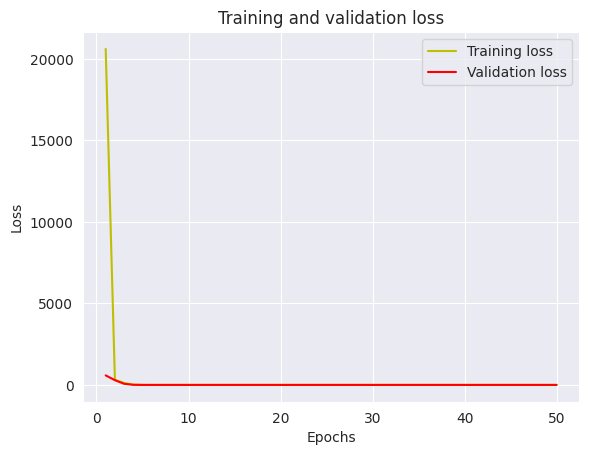

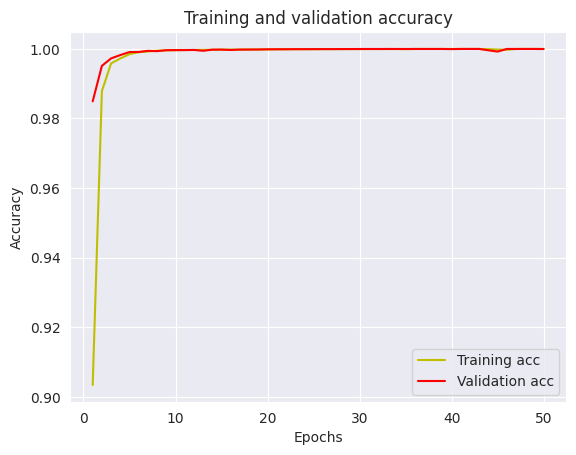

In [191]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()